In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix



In [16]:
# 1. Load and Calculate Risk Score
# Assuming your file is named 'risk_register.csv'
df = pd.read_excel('/content/risk_register.xlsx')


# Clean column names by stripping whitespace and renaming specific columns
df.columns = df.columns.str.strip()
df = df.rename(columns={'Likelihood Score (1–15)': 'Likelihood Score', 'Impact Score (1–9+C+E4': 'Impact Score'})

# Financial risk usually requires a unified score for prioritization
df['Risk_Score'] = df['Likelihood Score'] * df['Impact Score']



DataFrame Columns: Index(['No.', 'Main Risk Area', 'Sub-Risk Question', 'Likelihood Score (1–15)',
       'Impact Score (1–9+C+E4', 'Risk Level', 'Unnamed: 6'],
      dtype='object')


In [17]:
# 2. Refined Categorization (Target Variable)
def financial_risk_tier(row):
    score = row['Risk_Score']
    if score >= 40: return 'High'
    if score >= 15: return 'Medium'
    return 'Low'

df['Severity_Label'] = df.apply(financial_risk_tier, axis=1)



Mean Accuracy (Stratified CV): 0.87

Classification Report:
               precision    recall  f1-score   support

        High       1.00      0.86      0.93        37
      Medium       0.38      1.00      0.55         3

    accuracy                           0.88        40
   macro avg       0.69      0.93      0.74        40
weighted avg       0.95      0.88      0.90        40



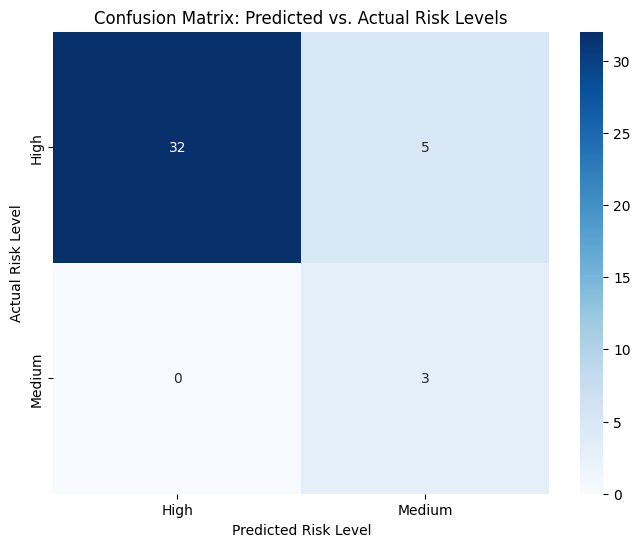

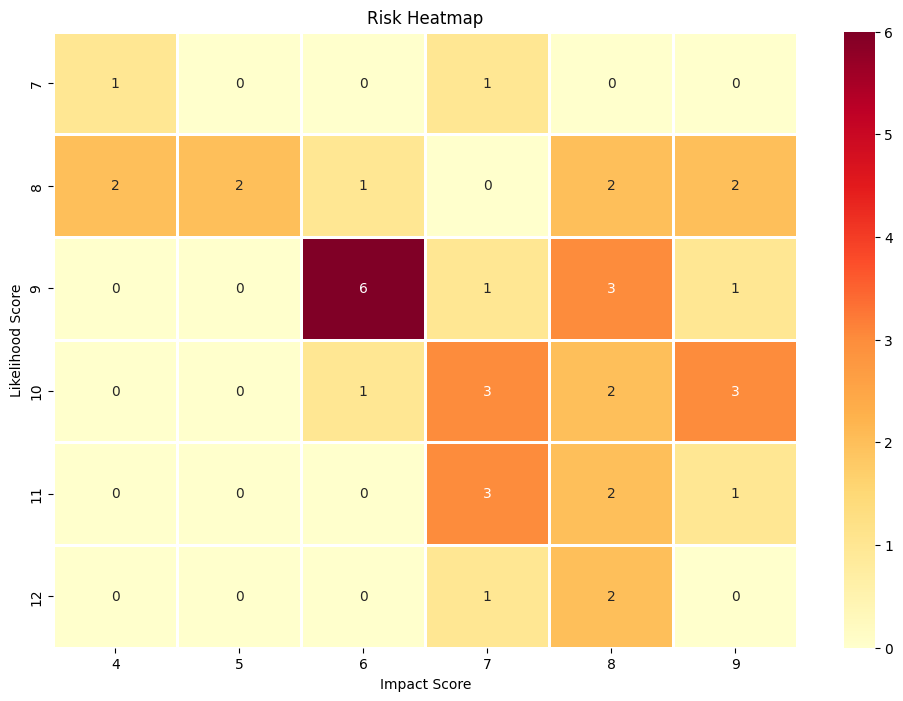

In [23]:
# 3. Stratified Cross-Validation (Best for small/imbalanced financial datasets)
X = df[['Likelihood Score', 'Impact Score']]
y = df['Severity_Label']

# We limit 'max_depth' and 'min_samples_leaf' to stop the model from memorizing individual rows
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,            # Prevents deep, complex trees
    min_samples_leaf=5,     # Each leaf must have at least 5 samples
    random_state=60,
    class_weight='balanced' # Handles the fact that you have very few 'Low' risks
)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

sccores = cross_val_score(model, X, y, cv=skf)
y_pred = cross_val_predict(model, X, y, cv=skf)

print(f"Mean Accuracy (Stratified CV): {sccores.mean():.2f}")
print("\nClassification Report:\n", classification_report(y, y_pred))
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
# Get unique classes from y and sort them for consistent order in confusion matrix
unique_classes = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=unique_classes)

# 2. Visualize using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes,
            yticklabels=unique_classes)

plt.title('Confusion Matrix: Predicted vs. Actual Risk Levels')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()
# 4. Advanced Risk Heatmap
plt.figure(figsize=(12, 8))
# Pivot to see the concentration of financial risks
pivot_table = df.pivot_table(index='Likelihood Score',
                             columns='Impact Score',
                             values='Risk_Score',
                             aggfunc='count').fillna(0)

sns.heatmap(pivot_table, annot=True, cmap="YlOrRd", fmt='g', linewidths=1)
plt.title("Risk Heatmap")
plt.xlabel("Impact Score")
plt.ylabel("Likelihood Score")
plt.show()